# S&P 500 Options: Feasibility Analysis

`config/setup.yaml` declares a cross-sectional short-volatility strategy: sell the at-the-money
straddle on S&P 500 constituents, delta-hedge, hold to maturity. Does the data support it?

## Learning objectives

- Price the round trip in the units the position earns on, read clearance off an exceedance curve
  scaled by it, and count the universe on the session the strategy acts on
- Measure how long the volatility premium stays put, and confirm the folds fit without the holdout

## Book reference. Chapter 6, Sections 6.2-6.6. Reads the straddle panel, the raw chains,
the underlying bars and `config/setup.yaml`, and writes nothing.

In [1]:
"""S&P 500 Options Case Study - Feasibility Analysis."""

import warnings

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import yaml
from ml4t.diagnostic.splitters.calendar import TradingCalendar

from case_studies.sp500_options._straddle_moves import straddle_premium_moves
from case_studies.sp500_options._underlying_returns import reconcile_underlying_log_returns
from case_studies.utils.feasibility import exceedance_curve, fold_timeline, panel_acf
from data import (
    load_sp500_daily_bars,
    load_sp500_options_straddles,
    load_sp500_options_straddles_raw,
    load_sp500_options_surface,
)
from utils.cv_splits import generate_cv_splits
from utils.paths import get_case_study_dir
from utils.style import COLORS, FIGSIZE, add_message_title

warnings.filterwarnings("ignore")

In [2]:
CASE_STUDY_ID = "sp500_options"
START_DATE = "2017-01-01"
END_DATE = "2021-12-31"

## Configuration

Every knob is read from `setup.yaml`, and Sections B and D compute on the development window alone.
Two derived quantities carry the strategy's shape into the diagnostics: a `top_k` book drawn from the
cheapest `liquid_quantile` of a date needs that many times more straddles quoted, and holding to
maturity pays the cheapest `cost_fractions` rung of the entry leg, not a round trip.

In [3]:
CASE_DIR = get_case_study_dir(CASE_STUDY_ID)
SETUP = yaml.safe_load((CASE_DIR / "config" / "setup.yaml").read_text())
HOLDOUT_START = str(SETUP["evaluation"]["holdout_start"])
HOLDOUT_END = str(SETUP["evaluation"]["holdout_end"])
PRIMARY_LABEL = SETUP["labels"]["primary"]
LABEL_BUFFER = SETUP["labels"]["buffer"]
CASCADE = SETUP["backtest"]["sweep"]["htm_cost_cascade"]
TOP_K = max(SETUP["backtest"]["sweep"]["top_k_grid"][PRIMARY_LABEL])
BREADTH_FLOOR = int(np.ceil(TOP_K / CASCADE["liquid_quantile"]))
ENTRY_COST_SHARE = min(CASCADE["cost_fractions"]) / 2
HORIZONS = sorted(
    {SETUP["labels"]["rebalance_step"][PRIMARY_LABEL], SETUP["decision"]["holding_period_days"]}
)
BUFFER_SESSIONS = int(LABEL_BUFFER.rstrip("D"))
SESSIONS = TradingCalendar(SETUP["evaluation"]["calendar"]).trading_days_between(
    START_DATE, HOLDOUT_START
)
print(f"Development {START_DATE} to {HOLDOUT_START} | sealed holdout to {HOLDOUT_END}")
print(f"Breadth floor {BREADTH_FLOOR} straddles | horizons {HORIZONS} sessions")

Development 2017-01-01 to 2021-01-01 | sealed holdout to 2021-12-31
Breadth floor 100 straddles | horizons [5, 10] sessions


## A. Orientation

A short at-the-money straddle collects the option premium and pays out whatever the underlying does,
so hedging the delta at each close leaves a position earning the gap between the implied volatility
set at entry and the volatility the stock goes on to realize. That gap is the volatility risk
premium, and selling it across several hundred names trades how richly each is priced. What
separates this from an equity strategy is the denominator: the return base is the premium, a few
percent of the share price, and the spread is quoted on that same premium. So, are
enough straddles quoted on the session the strategy acts on, is a typical move in the premium large
next to the cost of crossing it, and is there room for a walk-forward that never reads the holdout.

## B. Universe and cost feasibility

### B.1 Load and verify the declared universe. The straddle panel holds one row per symbol and session
where a listed expiry falls in the target window: the call and put nearest the money, paired at a
common strike and expiration, with the two-leg mid and the two-leg quoted spread.

In [4]:
straddles = load_sp500_options_straddles(start_date=START_DATE, end_date=END_DATE)
research = straddles.filter(pl.col("timestamp") < pl.lit(HOLDOUT_START).str.to_date())
assert research["instr_mid"].min() > 0, "a straddle mid is not a usable denominator"
timeline = research.select("timestamp").unique().sort("timestamp").with_row_index("s")
print(
    f"{research['symbol'].n_unique()} symbols, {len(research):,} straddle-days over "
    f"{len(timeline):,} sessions, {timeline['timestamp'][0]} to {timeline['timestamp'][-1]}, "
    f"entry maturity {research['instr_dte'].min()}-{research['instr_dte'].max()} days"
)

605 symbols, 289,356 straddle-days over 1,007 sessions, 2017-01-03 to 2020-12-31, entry maturity 25-35 days


### B.2 Breadth at every decision date. `setup.yaml::decision.entry_cadence` acts on the last session
of each week, so that is where the universe has to exist, and a chain carries a target maturity only
on the weeks a listed expiry falls in the window.

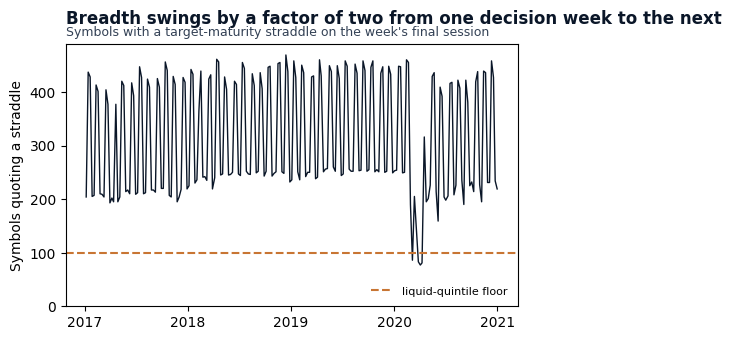

In [5]:
decisions = research.group_by(pl.col("timestamp").dt.truncate("1w")).agg(
    pl.col("timestamp").max().alias("decision_date")
)
entries = research.join(decisions, left_on="timestamp", right_on="decision_date")
breadth = (
    entries.group_by("timestamp")
    .agg(pl.col("symbol").n_unique().alias("n_symbols"))
    .sort("timestamp")
)

fig, ax = plt.subplots(figsize=FIGSIZE["single"])
ax.plot(breadth["timestamp"], breadth["n_symbols"], color=COLORS["blue"], lw=1.0)
ax.axhline(BREADTH_FLOOR, color=COLORS["copper"], ls="--", lw=1.5, label="liquid-quintile floor")
ax.set_ylim(0, None)
ax.set_ylabel("Symbols quoting a straddle")
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.legend(frameon=False, fontsize=8, loc="lower right")
add_message_title(
    ax,
    "Breadth swings by a factor of two from one decision week to the next",
    subtitle="Symbols with a target-maturity straddle on the week's final session",
)
plt.show()

### B.3 What the round trip costs, and what a move is worth. Every quote here stands at the decision,
which `setup.yaml::decision.execution_delay` fills on the next open. Selling the straddle crosses half
the quoted spread on each leg and buying it back crosses the other half, so a round trip costs one
full two-leg spread. Over the straddle mid, that is the share of the position's own return base the trade
gives up before anything happens - `setup.yaml::costs.components.option_spread` assumed, and
measured here. Against it sits the move in the premium of the straddles the panel selected on a
decision date, followed through their own strike and expiration, indexed by session, and divided by
the round trip that entry itself would cross. `straddle_premium_moves` documents all three.

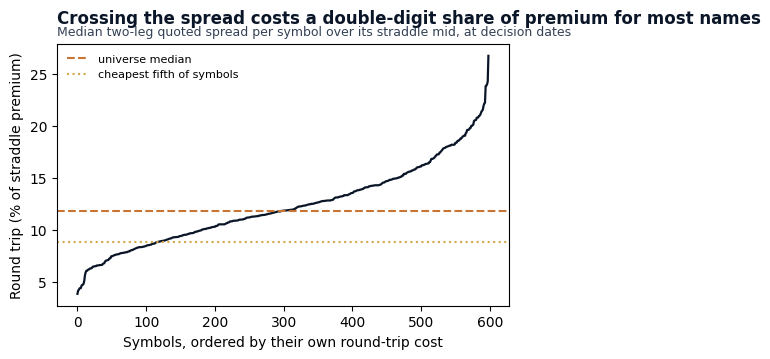

In [6]:
cost = (
    entries.group_by("symbol")
    .agg(
        pl.col("instr_rel_spread").median().alias("round_trip"),
        (pl.col("instr_spread") / pl.col("underlying_price") * 1e4).median().alias("spread_bps"),
    )
    .sort("round_trip")
)
COST_SHARE = float(cost["round_trip"].median())
LIQUID_CUT = float(cost["round_trip"].quantile(CASCADE["liquid_quantile"]))

fig, ax = plt.subplots(figsize=FIGSIZE["single"])
ax.plot(range(len(cost)), cost["round_trip"] * 100, color=COLORS["blue"], lw=1.6)
ax.axhline(COST_SHARE * 100, color=COLORS["copper"], ls="--", lw=1.5, label="universe median")
ax.axhline(
    LIQUID_CUT * 100, color=COLORS["amber"], ls=":", lw=1.5, label="cheapest fifth of symbols"
)
ax.set_xlabel("Symbols, ordered by their own round-trip cost")
ax.set_ylabel("Round trip (% of straddle premium)")
ax.legend(frameon=False, fontsize=8, loc="upper left")
add_message_title(
    ax,
    "Crossing the spread costs a double-digit share of premium for most names",
    subtitle="Median two-leg quoted spread per symbol over its straddle mid, at decision dates",
)
plt.show()

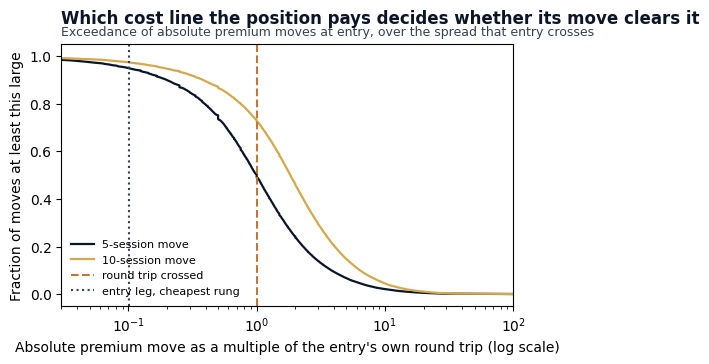

In [7]:
KEYS = ["symbol", "strike", "expiration", "timestamp"]
moves = straddle_premium_moves(
    load_sp500_options_straddles_raw(start_date=START_DATE, end_date=HOLDOUT_START, lazy=True),
    entries,
    horizons=HORIZONS,
).join(entries.select(*KEYS, "instr_rel_spread"), on=KEYS)
moves = moves.with_columns(
    (pl.col(f"h{h}") / pl.col("instr_rel_spread")).alias(f"h{h}") for h in HORIZONS
)

fig, ax = plt.subplots(figsize=FIGSIZE["single"])
for h, color in zip(HORIZONS, (COLORS["blue"], COLORS["amber"]), strict=True):
    multiple, fraction = exceedance_curve(moves[f"h{h}"].drop_nulls().to_numpy())
    ax.plot(multiple, fraction, color=color, lw=1.6, label=f"{h}-session move")
ax.axvline(1, color=COLORS["copper"], ls="--", lw=1.5, label="round trip crossed")
ax.axvline(
    ENTRY_COST_SHARE, color=COLORS["neutral"], ls=":", lw=1.5, label="entry leg, cheapest rung"
)
ax.set_xscale("log")
ax.set_xlim(0.03, 100)
ax.set_xlabel("Absolute premium move as a multiple of the entry's own round trip (log scale)")
ax.set_ylabel("Fraction of moves at least this large")
ax.legend(frameon=False, fontsize=8, loc="lower left")
add_message_title(
    ax,
    "Which cost line the position pays decides whether its move clears it",
    subtitle="Exceedance of absolute premium moves at entry, over the spread that entry crosses",
)
plt.show()

### B.4 How long the premium stays put. Re-ranking weekly is worth the turnover only if what the data
says at one decision date still says something at the next. The carrier is at-the-money implied
volatility less the volatility the underlying has just realized, computed inside each stable security
identity so a ticker succession does not become a return, and read from the daily surface summary,
which records the contract nearest the money in the maturity bucket every session where the paired
panel above needs both legs quotable. How long the gap lasts is an autocorrelation inside each
symbol, since the panel correlated as one series measures its joins; a lag is a row offset, so the
filter keeps only symbols observed on every session over half the window or more.

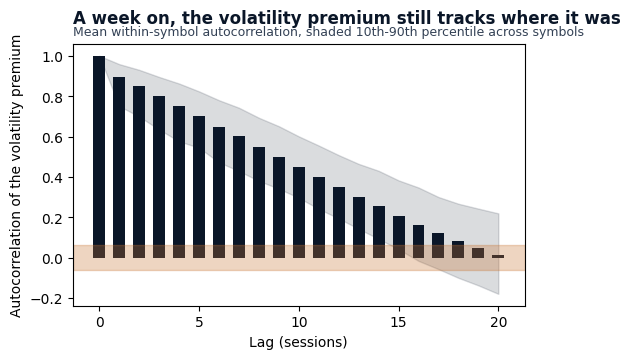

In [8]:
bars = load_sp500_daily_bars(start_date=START_DATE, end_date=HOLDOUT_START)
rolling = pl.col("clean_log_return").rolling_std(21, min_samples=21).over(["symbol", "sec_id"])
realized = (
    reconcile_underlying_log_returns(bars)
    .select("timestamp", "symbol", (rolling * np.sqrt(252)).alias("rv"))
    .drop_nulls()
)
surface = load_sp500_options_surface(start_date=START_DATE, end_date=HOLDOUT_START)
span = pl.col("s").max().over("symbol") - pl.col("s").min().over("symbol") + 1
premium = (
    surface.select("timestamp", "symbol", "iv_30_atm")
    .drop_nulls()
    .join(realized, on=["timestamp", "symbol"], how="inner")
    .join(timeline, on="timestamp")
    .with_columns((pl.col("iv_30_atm") - pl.col("rv")).alias("vrp"))
    .filter((pl.len().over("symbol") == span) & (pl.len().over("symbol") >= SESSIONS // 2))
    .sort(["symbol", "timestamp"])
)
acf = panel_acf(
    premium, entity_col="symbol", value_col="vrp", max_lags=max(HORIZONS) * 2, min_obs=SESSIONS // 2
)

fig, ax = plt.subplots(figsize=FIGSIZE["single"])
ax.fill_between(acf["lag"], acf["acf_p10"], acf["acf_p90"], color=COLORS["blue"], alpha=0.15)
ax.bar(acf["lag"], acf["acf"], color=COLORS["blue"], width=0.6)
ax.axhspan(-acf["band"][0], acf["band"][0], color=COLORS["copper"], alpha=0.3)
ax.set_xlabel("Lag (sessions)")
ax.set_ylabel("Autocorrelation of the volatility premium")
add_message_title(
    ax,
    "A week on, the volatility premium still tracks where it was",
    subtitle="Mean within-symbol autocorrelation, shaded 10th-90th percentile across symbols",
)
plt.show()

### B.5 Move scale against cost. The statistic is the median across entries of the move at the shorter
horizon over the round trip that entry crosses; the clearance shares count entries above each cost
line. Neither says the position is profitable: the move is unsigned and a seller keeps only small ones.

In [9]:
short = moves[f"h{HORIZONS[0]}"].drop_nulls()
print(
    f"Round trip {cost['round_trip'].min():.3f}-{cost['round_trip'].max():.3f} of premium, median"
    f" {COST_SHARE:.4f}; on notional {cost['spread_bps'].median():.1f} bps\n"
    f"Median {HORIZONS[0]}-session move {short.median():.2f}x the round trip; over it "
    f"{(short > 1).mean():.3f}, over the entry leg {(short > ENTRY_COST_SHARE).mean():.3f}\n"
    f"Premium mean {premium['vrp'].mean():.4f} over {premium['symbol'].n_unique()} symbols, positive"
    f" {(premium['vrp'] > 0).mean():.3f}, autocorrelation {acf['acf'][HORIZONS[0]]:.3f} a week out"
)

Round trip 0.038-0.267 of premium, median 0.1184; on notional 70.1 bps
Median 5-session move 1.00x the round trip; over it 0.497, over the entry leg 0.948
Premium mean -0.0003 over 194 symbols, positive 0.598, autocorrelation 0.703 a week out


The median symbol gives up 0.1184 of the straddle premium to cross the two-leg spread twice, which
is 70.1 bps of underlying notional. The median entry's five-session move matches the round trip it
crosses, at 1.00x, and 0.497 of entries clear it; at the entry leg's cheapest rung, 0.948 clear. The premium averages
-0.0003 volatility points over 194 symbols, is positive on 0.598 of days, and autocorrelates 0.703 at
a lag of one week.

## C. Design decisions

### C.1 Cadence. `setup.yaml::decision.entry_cadence` enters at the Friday close and executes at the
Monday open; `hedge_cadence` re-hedges the delta at each close. B.4 supports weekly entry: within a
symbol the premium still resembles itself a rebalance later, so the cadence is not sampling noise.
Whether the ranking across symbols is as stable belongs to the label evaluation, which scores a
signal rather than a carrier. B.2 constrains the cadence from the other side, since the universe
available to rank doubles and halves week to week.

### C.2 Kill conditions. Three thresholds send the strategy back to the drawing board: the premium
compressing below its floor for longer than a rebalance cycle, tested at label evaluation in Chapter
7; cost consuming more of the premium than the cascade's cheapest rung leaves, at the cost stage in
Chapter 18; and gamma losses over a rolling window exceeding the premium collected, under the risk
overlay in Chapter 19. B.3, B.4 and B.5 set the baselines they are read against.

### C.3 Mapping class. `setup.yaml::mapping.class` ranks symbols by expected short-straddle return
and holds the top `top_k`, sized on vega so a high-priced name does not dominate a book of
volatility exposures. Three choices follow from B.3, declared under
`setup.yaml::backtest.sweep.htm_cost_cascade` and dispatched by the Chapter 18 notebooks: hold to
maturity, rank only inside the cheapest `liquid_quantile` of a date, and sweep `cost_fractions`.

## D. Walk-forward structure

### D.1 Effective sample size. What evaluation spends is decision dates, not rows. A straddle
entered on the last of them resolves `setup.yaml::labels.buffer` later, and `generate_cv_splits`
reads that buffer in trading sessions, so the seal counts over the timeline, not the calendar.

In [10]:
outcome_seal = timeline["timestamp"][-(BUFFER_SESSIONS + 1)]
print(
    f"Trading days {SESSIONS} | decision dates "
    f"{len(decisions):,} | symbols per decision {breadth['n_symbols'].min()} to "
    f"{breadth['n_symbols'].max()}, median {breadth['n_symbols'].median():.0f} | under the book "
    f"floor on {breadth.filter(pl.col('n_symbols') < BREADTH_FLOOR).height} of {len(breadth)} "
    f"dates | outcomes resolve inside the holdout after {outcome_seal}"
)

Trading days 1007 | decision dates 209 | symbols per decision 77 to 469, median 252 | under the book floor on 4 of 209 dates | outcomes resolve inside the holdout after 2020-11-10


### D.2 Fold demonstration. `generate_cv_splits` derives the folds from `setup.yaml::evaluation` alone,
numbering them backwards from the holdout. Between each training and validation block sits a purge gap
the width of the label buffer, stopping a straddle sold inside training from expiring inside
validation. The figure draws the boundaries the splitter returns, not a second copy.

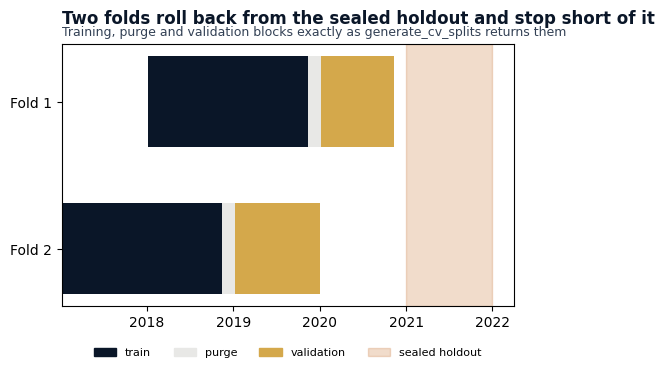

In [11]:
splits = generate_cv_splits(
    research.select("timestamp").unique(),
    case_study_id=CASE_STUDY_ID,
    label_buffer=LABEL_BUFFER,
    date_col="timestamp",
)
last_val = max(s["val_end"] for s in splits)
assert len(splits) == SETUP["evaluation"]["n_splits"], "fold count differs from setup.yaml"
assert last_val < np.datetime64(HOLDOUT_START), "a fold reaches into the holdout"

fig, ax = plt.subplots(figsize=FIGSIZE["single"])
fold_timeline(ax, splits, holdout=(HOLDOUT_START, HOLDOUT_END))
add_message_title(
    ax,
    "Two folds roll back from the sealed holdout and stop short of it",
    subtitle="Training, purge and validation blocks exactly as generate_cv_splits returns them",
)
plt.show()

## E. Derived artifacts. Nothing: the universe is whatever carries a quoted straddle that day and the liquid filter is recomputed per rebalance date at the cost stage, so nothing is written here.

## F. Findings vs `setup.yaml`. One row per knob: its evidence, and what would change it.

| Knob | Evidence | Revise it when |
|---|---|---|
| `universe.underlying` | B.2 breadth per decision date | breadth falls under the count the liquid quintile needs to fill a book of `top_k` |
| `decision.entry_cadence` | B.2 breadth, B.4 persistence | the premium decays inside one rebalancing interval, or coverage stops cycling with the expiry calendar |
| `backtest.sweep.htm_cost_cascade` | B.3 cost per symbol and exceedance | the quoted spread narrows enough that the exit leg stops deciding whether a move clears its cost |
| `evaluation.n_splits` | D.1 decision dates, D.2 boundaries | the folds no longer fit the development window ahead of the outcome seal |

In [12]:
print(
    f"universe.underlying {SETUP['universe']['underlying']}, {research['symbol'].n_unique()} symbols"
    f" quoted, cheapest fifth of them at or under {LIQUID_CUT:.4f} of premium\n"
    f"decision.entry_cadence {SETUP['decision']['entry_cadence']} | labels.primary {PRIMARY_LABEL} |"
    f" labels.buffer {LABEL_BUFFER} | top_k {CASCADE['top_k']} of the cheapest "
    f"{CASCADE['liquid_quantile']}, cost_fractions {CASCADE['cost_fractions']}\n"
    f"evaluation.n_splits {SETUP['evaluation']['n_splits']}, generated {len(splits)}, last "
    f"validation ends {last_val.date()}, holdout untouched"
)

universe.underlying sp500_constituents, 605 symbols quoted, cheapest fifth of them at or under 0.0887 of premium
decision.entry_cadence weekly_friday | labels.primary ret_to_expiry | labels.buffer 35D | top_k 20 of the cheapest 0.2, cost_fractions [0.203, 0.5, 0.75, 1.0]
evaluation.n_splits 2, generated 2, last validation ends 2020-11-10, holdout untouched


The development window quotes 605 symbols, of which the cheapest fifth crosses at or under 0.0887 of
premium. Breadth runs from 77 to 469 straddles per decision date and falls under the floor a top-20
book needs on 4 of 209. Two folds are generated, the last validation ending 2020-11-10, which is also
the last date whose outcome resolves before the holdout.

## Key takeaways

1. **Read cost against the base the position earns on**, not against the notional it is quoted on.
2. **Count the universe on the session the strategy acts on**, never anywhere in the week.
3. **Follow a contract by its own strike and expiration**, index its horizon by sessions not rows, and
   correlate inside each entity, never across the stack.

### Known limitations. Cost here is the quoted spread alone: commission, the equity leg of the daily
hedge and the margin the position ties up need a notional and enter at the cost stage. The B.3 moves
are unhedged marks, and re-hedging the delta each close removes part of what a seller would take.
B.4's implied volatility is the nearest-the-money contract in a maturity bucket, not a fixed tenor, so
a change of expiry moves the carrier alongside the premium.

**Next**: labels at the declared horizon, built on this development window.